# Open-Channel and Pressure-Pipe Hydraulics

Two invented problems: a rectangular flood channel running 320 cfs behind a
check dam, and a reservoir outlet pipe with a high point that flirts with
sub-atmospheric pressure.

In [1]:
from civilpy.water_resources.open_channel import RectangularChannel

ch = RectangularChannel(width=12.0, n=0.015, slope=0.0009)
Q = 320.0
yn, yc = ch.normal_depth(Q), ch.critical_depth(Q)
print(f"normal depth   yn = {yn:.2f} ft")
print(f"critical depth yc = {yc:.2f} ft  (mild slope: yn > yc)")
print(f"Froude at yn = {ch.froude(Q, yn):.2f}")

normal depth   yn = 4.70 ft
critical depth yc = 2.81 ft  (mild slope: yn > yc)
Froude at yn = 0.46


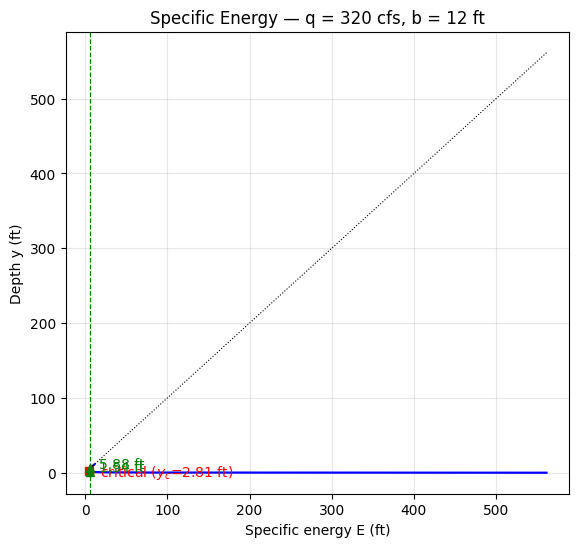

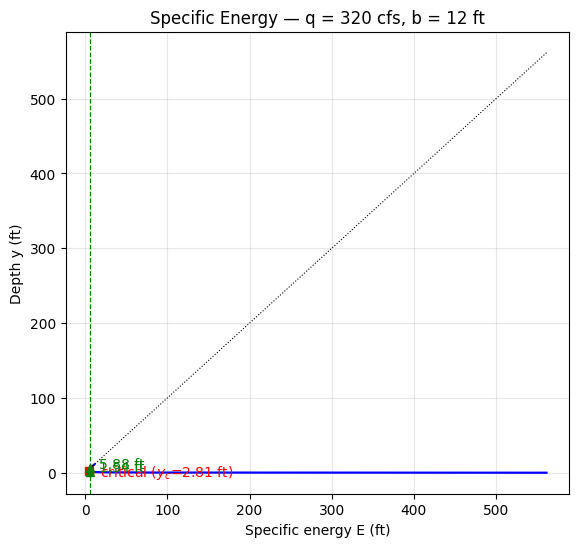

In [2]:
ch.plot_specific_energy(Q, energy=ch.specific_energy(Q, yn) + 1.0)

## M1 backwater behind the check dam

The dam holds the water surface at 8.4 ft.  Marching upstream, the profile
relaxes toward normal depth — the classic M1 curve, classified automatically.

profile class: M1


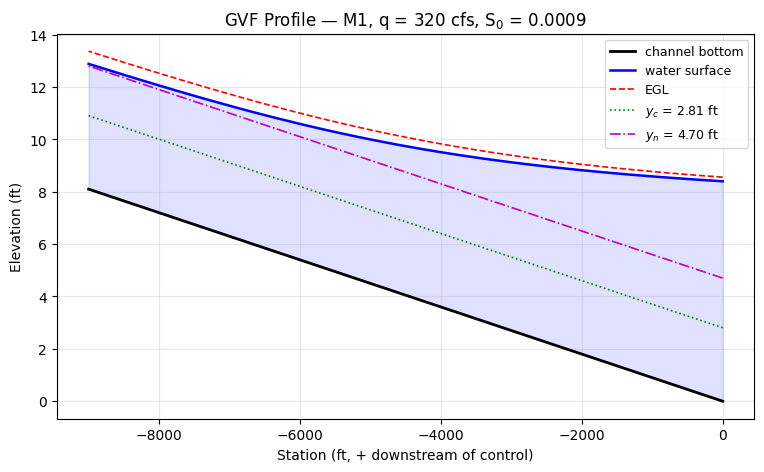

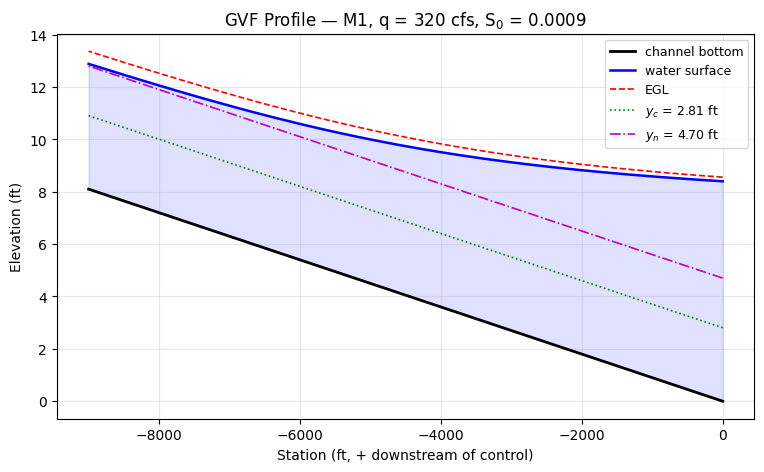

In [3]:
print("profile class:", ch.classify_profile(Q, 8.4))
ch.plot_gvf_profile(Q, y_control=8.4, length=9000.0)

## Reservoir outlet: EGL and HGL

A 16-in line drops from a reservoir at El. 318 over a saddle at El. 315 —
watch the HGL dip below the pipe crown on the saddle.

In [4]:
from civilpy.water_resources.pipe_flow import PipeSegment, PipeProfile

line = PipeProfile(
    [PipeSegment(420.0, 16.0, f=0.019, k_minor=0.5),   # entrance leg
     PipeSegment(380.0, 16.0, f=0.019, k_minor=0.25),  # over the saddle
     PipeSegment(600.0, 16.0, f=0.019, k_minor=0.25)], # down to the valve
    node_elevations_ft=[295.0, 315.0, 304.0, 262.0],
    source_energy_ft=318.0, q_cfs=9.0)
print(f"velocity = {line.velocity_fps(0):.1f} fps")
print(f"total head loss = {line.total_head_loss():.1f} ft")
flagged = line.low_pressure_stations()
print("sub-atmospheric stations:", [f"{x:.0f} ft ({m:+.1f} ft)"
                                    for x, m in flagged])

velocity = 6.4 fps
total head loss = 13.5 ft
sub-atmospheric stations: ['420 ft (-1.8 ft)', '420 ft (-2.0 ft)']


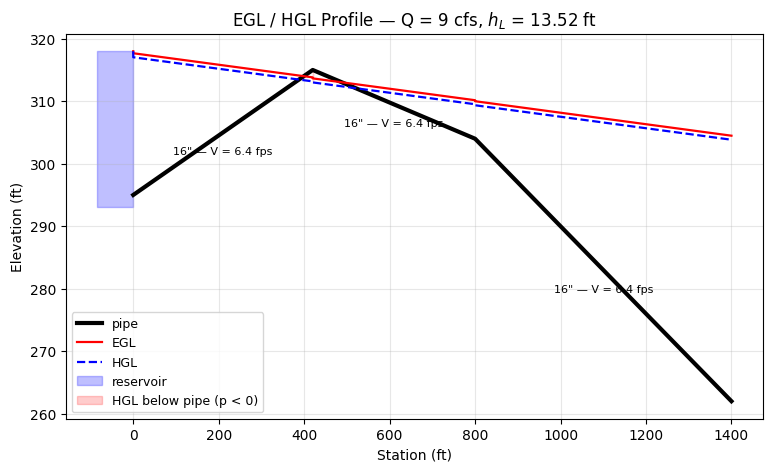

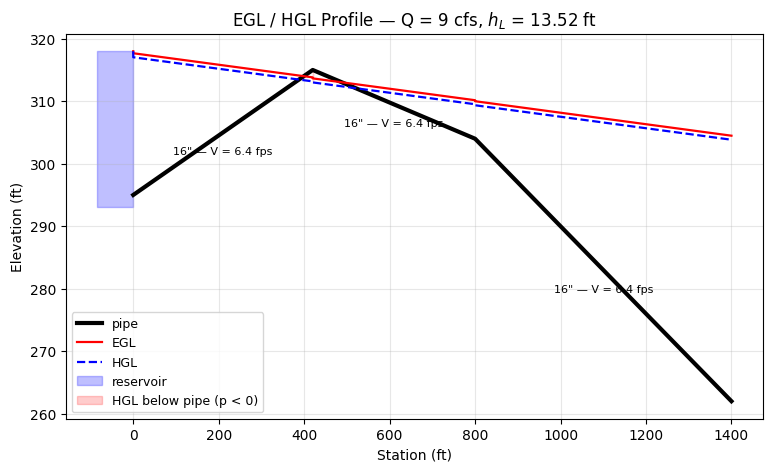

In [5]:
line.plot_egl_hgl()

Where the dashed HGL drops below the pipe profile, pressure is below
atmospheric — the negative margins printed above say by how much.  Lowering the
saddle, upsizing the pipe, or throttling at the downstream end all show up
immediately in this picture.